---
#### Practise: Unsupervised Learning: Anomaly detection, Clustering

##### Date: 2026-01-26

Dataset: OnlineRetail 

In [1]:
import pandas as pd

df = pd.read_excel('Online Retail.xlsx') # !! замінити на свій шлях !!

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
Task 1. EDA 

In [3]:
df.tail(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [4]:
df.sample(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
349872,C567540,23295,SET OF 12 MINI LOAF BAKING CASES,-2,2011-09-21 10:00:00,0.83,12384.0,Switzerland
92888,544207,22219,LOVEBIRD HANGING DECORATION WHITE,2,2011-02-17 10:34:00,1.63,NaN,United Kingdom


In [5]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [6]:
df['Country'].value_counts(normalize=True)

Country
United Kingdom          0.914320
Germany                 0.017521
France                  0.015790
EIRE                    0.015124
Spain                   0.004674
Netherlands             0.004375
Belgium                 0.003818
Switzerland             0.003694
Portugal                0.002803
Australia               0.002323
Norway                  0.002004
Italy                   0.001482
Channel Islands         0.001399
Finland                 0.001283
Cyprus                  0.001148
Sweden                  0.000853
Unspecified             0.000823
Austria                 0.000740
Denmark                 0.000718
Japan                   0.000661
Poland                  0.000629
Israel                  0.000548
USA                     0.000537
Hong Kong               0.000531
Singapore               0.000423
Iceland                 0.000336
Canada                  0.000279
Greece                  0.000269
Malta                   0.000234
United Arab Emirates    0.000125
Eu

In [7]:
df.shape

(541909, 8)

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


---
Task 2. Preprocessing (clear data and delete NaN) + create columns TotalPrice + create snapshot_date ( max date )

In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df[df['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [13]:
df_copy = df.copy()

df_copy.dropna().shape, df.shape

((406829, 8), (541909, 8))

In [14]:
df_copy.drop_duplicates().shape, df.shape

((536641, 8), (541909, 8))

In [15]:
dublicated_ = df[df.duplicated()]
dublicated_ 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [16]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2369
REGENCY CAKESTAND 3 TIER               2200
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1727
LUNCH BAG RED RETROSPOT                1638
                                       ... 
Missing                                   1
historic computer difference?....se       1
DUSTY PINK CHRISTMAS TREE 30CM            1
WRAP BLUE RUSSIAN FOLKART                 1
PINK BERTIE MOBILE PHONE CHARM            1
Name: count, Length: 4223, dtype: int64

In [17]:
df.groupby('Description')['InvoiceNo'].count()

Description
20713                               1
 4 PURPLE FLOCK DINNER CANDLES     41
 50'S CHRISTMAS GIFT BAG LARGE    130
 DOLLY GIRL BEAKER                181
 I LOVE LONDON MINI BACKPACK       88
                                 ... 
wrongly marked carton 22804         1
wrongly marked. 23343 in box        1
wrongly sold (22719) barcode        1
wrongly sold as sets                1
wrongly sold sets                   1
Name: InvoiceNo, Length: 4223, dtype: int64

In [23]:
df = df.dropna(subset = ['CustomerID'])

In [18]:
# create columns TotalPrice

df["TotalPrice"] = df['Quantity'] * df['UnitPrice']
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [26]:
df.shape

(406829, 10)

In [25]:
# create snapshot_date (max date)

snapshot_date = df['InvoiceDate'].max()
snapshot_date 

Timestamp('2011-12-09 12:50:00')

---
Task 3. Create RFM

In [27]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]


In [30]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40
...,...,...,...
18280.0,277,1,180.60
18281.0,180,1,80.82
18282.0,7,3,176.60


---
Task 4. Scalling data

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [34]:
rfm_scaled

array([[ 2.32202285, -0.32936215, -0.23100099],
       [-0.89373323,  0.20610242,  0.29343167],
       [-0.1691956 , -0.11517632, -0.01231622],
       ...,
       [-0.83418219, -0.22226923, -0.20951263],
       [-0.87388289,  1.16993863,  0.02390005],
       [-0.48680114, -0.22226923, -0.00744423]])

---
Task 5. Fine-tuning K-Means use Elbow Method & Silhouette Score


In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# В циклі пройти по кластерах від 2 до 10, та порахувати iteria km.inertia_ (приклад)

inertias = []

K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

inertias

[9423.823814617108,
 5527.270271017527,
 4081.5943728628113,
 3020.0156481950103,
 2554.8214482143,
 1924.1765194325912,
 1593.6352548770997,
 1430.7725598849615]

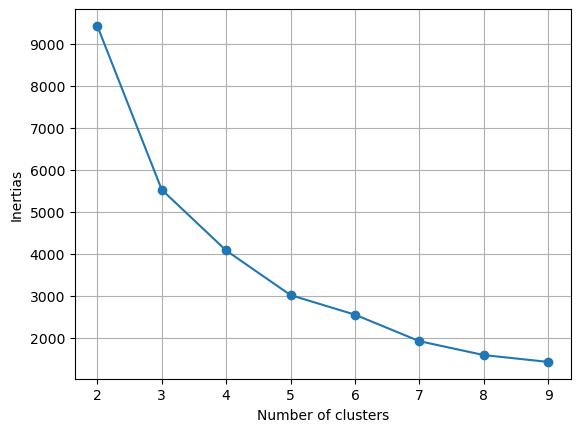

In [39]:
plt.plot(K_range,inertias, marker = 'o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertias')
plt.grid()

In [41]:
# Silhouette Score

from sklearn.metrics import silhouette_score

# В циклі пройти по кластерах від 2 до 10, та порахувати silhouette_score 

sil_score = []

K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    print(k, silhouette_score(rfm_scaled, labels))
    sil_score.append(silhouette_score(rfm_scaled, labels))

# 1 - good
# 0 - cluster with problem
# <0 - bad

2 0.5568161675254506
3 0.5881863741362154
4 0.6142804196098184
5 0.589875763645933
6 0.5152073810193639
7 0.5213735438041367
8 0.493800404777397
9 0.4692562907107869


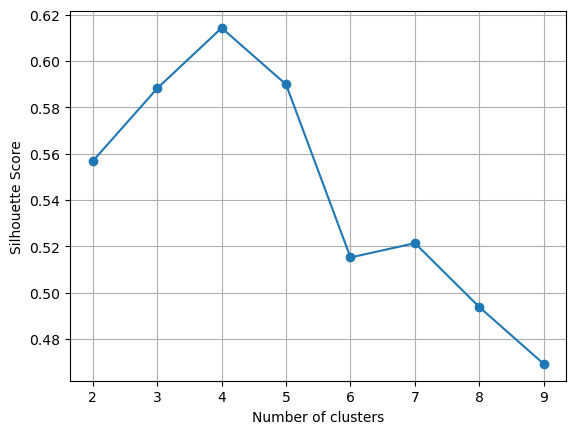

In [42]:
plt.plot(K_range,sil_score, marker = 'o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid()

---
Task 6. Create final model. Add visualization

In [43]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)


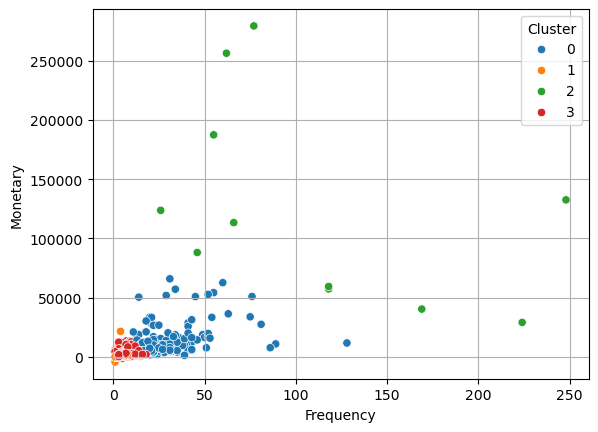

In [45]:
import seaborn as sns

sns.scatterplot(data = rfm, x = "Frequency", y = "Monetary", hue = "Cluster", palette='tab10')
plt.grid()

---
Task 7. Final result and variant of solve

In [47]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,9.752577,28.510309,12168.264691
1,247.927577,1.805942,455.110716
2,4.090909,109.909091,124312.306364
3,41.780906,4.370550,1320.981506


---
Task 8. Anomaly detection. Scalling data 

In [57]:
features = df[["Quantity", "UnitPrice", "TotalPrice"]]
X = df[features]

ValueError: Boolean array expected for the condition, not int64

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

NameError: name 'X' is not defined

---
Task 9. Isolation Forest. Create model with contamination = 0.01

In [ ]:
# you model
# iso.decision_function(X_scaled)
# iso.predict(X_scaled)

from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination = 0.01, random_state = 42)

iso.fit(X_scaled)
df['IF_score'] = iso.decision_function(X_scaled)
df['IF_Anomaly'] = iso.predict(X_scaled)


NameError: name 'X_scaled' is not defined

---
Task 10. LOF. Create model with n_neighbors = 20 and contamination=0.01

In [58]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20,contamination = 0.01)
df['LOF_Anomaly'] = lof.fit_predict(X_scaled)


NameError: name 'X_scaled' is not defined

In [ ]:
df['LOF_Anomaly'].value_counts()

---
Task 11. Final result

In [49]:
sns.scatterplot(data=df.sample(5000), x="UnitPrice", y="Quantity", hue="IF_Anomaly")
plt.title("Isolation Forest Anomalies")
plt.show()


ValueError: Could not interpret value `IF_Anomaly` for `hue`. An entry with this name does not appear in `data`.

In [50]:
(df["IF_Anomaly"] == -1).mean()

KeyError: 'IF_Anomaly'

In [ ]:
((df["IF_anomaly"] == -1) & (df["LOF_Anomaly"] == -1)).sum()

KeyError: 'IF_anomaly'

In [ ]:
for c in [0.005, 0.01, 0.02]:
    iso = IsolationForest(contamination=c, random_state=42)
    preds = iso.fit_predict(X_scaled)
    print(c, (preds == -1).mean())


In [ ]:
for k in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=k, contamination=0.01)
    preds = lof.fit_predict(X_scaled)
    print(k, (preds == -1).mean())


In [59]:
df['IF_anomaly'].value_counts()

KeyError: 'IF_anomaly'

In [ ]:
scores = []
conts = [0.005, 0.01, 0.02]

for c in conts:
    iso = IsolationForest(contamination=c)
    preds = iso.fit_predict(X_scaled)
    scores.append((preds == -1).sum())

plt.plot(conts, scores)
plt.title("Anomalies vs Contamination")
plt.show()
